In [2]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [3]:
data=pd.read_csv("/content/diabetes (1).csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
print(data.isin([0]).sum())

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


When we apply `StandardScaler`:

*   **`sc.fit_transform(x_train)`**: The `fit` method *learns* the scaling parameters (like the mean and standard deviation) from the `x_train` data. Immediately after, the `transform` method applies these *learned* parameters to scale `x_train`. This means `x_train` is centered around 0 and scaled to have a unit variance.

*   **`sc.transform(x_test)`**: We then use *the same scaling parameters learned from `x_train`* to `transform` (scale) `x_test`. We **do not** use `fit_transform` on `x_test` because that would mean `x_test`'s scaling parameters would be learned independently. This would lead to data leakage, where information from the test set subtly influences the training process, resulting in an overly optimistic evaluation of the model's performance on unseen data. The idea is to treat `x_test` as completely new, unseen data, so it should be scaled based *only* on the characteristics of the training data.

In [7]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]
print(x)
print("next")
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(614, 8)
(154, 8)
(614,)
(154,)


In [9]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
print(x_train)
print(x_test)

[[ 0.90832902  0.91569367  0.44912368 ...  0.37852648  0.67740401
   1.69955804]
 [ 0.03644676 -0.75182191 -0.47230103 ... -0.50667229 -0.07049698
  -0.96569189]
 [-1.12606292  1.38763205  1.06340683 ...  2.54094063 -0.11855487
  -0.88240283]
 ...
 [ 0.03644676 -0.84620959 -0.21634972 ... -0.94927168 -0.95656442
  -1.04898095]
 [ 2.0708387  -1.12937261  0.24436264 ... -0.26640405 -0.50001442
   0.11706589]
 [ 0.32707418  0.47521786  0.65388473 ... -4.07275877  0.52121586
   2.94889395]]
[[-0.8354355   2.45735903  0.34674316 ...  1.35224513  2.78594417
  -0.96569189]
 [-0.54480808 -0.43719633  0.24436264 ...  0.17619533 -0.1876381
  -0.88240283]
 [ 0.03644676 -1.41253563 -0.36992051 ...  0.22677812 -0.22668514
  -0.71582471]
 ...
 [ 0.03644676  0.66399321  0.85864578 ...  1.4913478   0.53623395
  -0.96569189]
 [-0.25418066 -0.15403331  0.24436264 ... -0.74694053 -1.07971278
  -0.79911377]
 [-0.8354355  -0.43719633  0.14198211 ... -0.17788417  1.06487079
  -0.79911377]]


In [11]:
#linear regression
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)

LogisticRegression(random_state=0)

In [14]:
y_pred=classifier.predict(x_test)
x=np.concatenate((y_pred.reshape(len(y_pred),1),y_test.values.reshape(len(y_test),1)), axis=1)
print(x)

[[1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]

In [15]:
#confusion matrix
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(accuracy_score(y_test,y_pred))

[[98  9]
 [18 29]]
0.8246753246753247


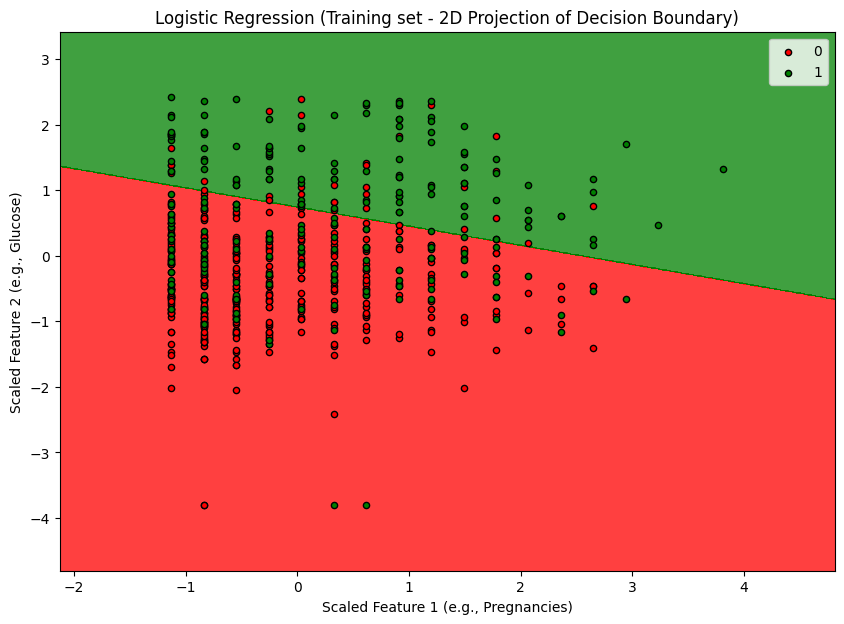

In [18]:
#graphical visualization of logistic regression
import numpy as np
import matplotlib.pyplot as plt # Corrected import
from matplotlib.colors import ListedColormap

# For visualization, we typically select two important features and project the decision boundary onto them.
# The classifier was trained on 8 scaled features, so we will create a meshgrid in the scaled space
# for two features, and set the remaining features to their mean values from the training set.

# Select the first two features from x_train for visualization (these are already scaled)
X_visual_train = x_train[:, [0, 1]]

# Define ranges for the meshgrid based on the selected scaled features
X1_min, X1_max = X_visual_train[:, 0].min() - 1, X_visual_train[:, 0].max() + 1
X2_min, X2_max = X_visual_train[:, 1].min() - 1, X_visual_train[:, 1].max() + 1

# Create meshgrid for the two selected features
X1, X2 = np.meshgrid(np.arange(X1_min, X1_max, 0.01),
                     np.arange(X2_min, X2_max, 0.01))

# To predict on the meshgrid using the 8-feature classifier, we need to fill the other 6 features
# with constant values (e.g., their means from the scaled x_train).
mean_other_features_scaled = np.mean(x_train[:, 2:], axis=0)
other_features_meshgrid = np.tile(mean_other_features_scaled, (X1.size, 1))

# Combine meshgrid points for the first two features with the constant mean values for the rest
meshgrid_input_scaled = np.concatenate((X1.ravel().reshape(-1, 1), X2.ravel().reshape(-1, 1), other_features_meshgrid), axis=1)

# Predict the outcomes on the meshgrid points using the trained classifier
Z = classifier.predict(meshgrid_input_scaled).reshape(X1.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot the actual data points from the training set (using the first two scaled features)
for i, j in enumerate(np.unique(y_train)):
    plt.scatter(X_visual_train[y_train == j, 0], X_visual_train[y_train == j, 1],
                color=ListedColormap(('red', 'green'))(i), label=j, s=20, edgecolor='k') # Changed 'c' to 'color'

plt.title('Logistic Regression (Training set - 2D Projection of Decision Boundary)')
plt.xlabel('Scaled Feature 1 (e.g., Pregnancies)')
plt.ylabel('Scaled Feature 2 (e.g., Glucose)')
plt.legend()
plt.show()